Data cleaning in python is done using pandas, handling null values,dropping missing values,
dropping columns with wrong data,filling null values, all things part of cleaning.

In [2]:
import pandas as pd
df=pd.read_csv('North America Restaurants.csv')

In [ ]:
#check entire data frame for missing values
#this returns true/false for every cell
df.isna()

,name,city,state,zipcode,country,cuisines,pickup_enabled,delivery_enabled,weighted_rating_value,aggregated_rating_count
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1495,False,False,False,False,False,False,False,False,False,False
1496,False,False,False,False,False,False,False,False,False,False
1497,False,False,False,False,False,False,False,False,False,False
1498,False,False,False,False,False,False,False,False,False,False


In [2]:
import pandas as pd
import numpy as np

data={
    'Employee':['Asha','Bala','Chitra','Deepa','Esha','Farhan'],
    'Department':['HR','IT','IT','Finance','HR','IT'],
    'Age':[25,32,np.nan,29,41,np.nan],
    'Salary':[40000,80000,55000,np.nan,50000,72000],
    'Performance_Score':[85,90,78,np.nan,88,92]

}
df=pd.DataFrame(data)
df

,Employee,Department,Age,Salary,Performance_Score
0,Asha,HR,25.0,40000.0,85.0
1,Bala,IT,32.0,80000.0,90.0
2,Chitra,IT,NaN,55000.0,78.0
3,Deepa,Finance,29.0,NaN,NaN
4,Esha,HR,41.0,50000.0,88.0
5,Farhan,IT,NaN,72000.0,92.0


In [3]:
df.isna()

,Employee,Department,Age,Salary,Performance_Score
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,True,True
4,False,False,False,False,False
5,False,False,True,False,False


In [ ]:
#count of missing values column-wise
df.isna().sum()

Employee             0
Department           0
Age                  2
Salary               1
Performance_Score    1
dtype: int64

In [ ]:
#rows with any missing columns
df[df.isna().any(axis=1)]

,Employee,Department,Age,Salary,Performance_Score
2,Chitra,IT,NaN,55000.0,78.0
3,Deepa,Finance,29.0,NaN,NaN
5,Farhan,IT,NaN,72000.0,92.0


Axis tells which direction to move in for pandas

rows -> move horizontally
columns go vertically

There are only two possible axes:
axis=0    means operate down the rows(column-wise)
axis=1    means operate across the columns (row-wise)

In [6]:
#dropping missing values
df.dropna()

#drop any rows with missing values

,Employee,Department,Age,Salary,Performance_Score
0,Asha,HR,25.0,40000.0,85.0
1,Bala,IT,32.0,80000.0,90.0
4,Esha,HR,41.0,50000.0,88.0


In [ ]:
df.dropna(how='all')
#drops any row which has all values missing
#how=all is strict deletion

,Employee,Department,Age,Salary,Performance_Score
0,Asha,HR,25.0,40000.0,85.0
1,Bala,IT,32.0,80000.0,90.0
2,Chitra,IT,NaN,55000.0,78.0
3,Deepa,Finance,29.0,NaN,NaN
4,Esha,HR,41.0,50000.0,88.0
5,Farhan,IT,NaN,72000.0,92.0


In [9]:
#based on threshold
df.dropna(thresh=4)

#keeps rows with atleast 4 non-null values

,Employee,Department,Age,Salary,Performance_Score
0,Asha,HR,25.0,40000.0,85.0
1,Bala,IT,32.0,80000.0,90.0
2,Chitra,IT,NaN,55000.0,78.0
4,Esha,HR,41.0,50000.0,88.0
5,Farhan,IT,NaN,72000.0,92.0


In [10]:
#drop columns with missing values
df.dropna(axis=1)

,Employee,Department
0,Asha,HR
1,Bala,IT
2,Chitra,IT
3,Deepa,Finance
4,Esha,HR
5,Farhan,IT


Imputation- Filling missing values

In python both np.nan and None are missing data

np.nan stands for not a number 
None is for missing data

When do we drop?
1. Drop when missing values are very small,
Example- dataset has 10,000 rows, only 20 rows contain missing values, dropping them won't
affect analysis

2. Entire column is useless or unnecessary data or maybe entire column is empty


When will dropping be a problem?
When dropping we remove other valuable information too, to avoid this we prefer filling
in some cases

Types of Imputation-
- Mean imputation
- Median imputation
- Mode imputation
- Time series imputation

Dropping can sometimes reduce dataset size and dropping them might not make sense.

Dropping is better when there are too many missing values in a column,

Sometimes missing values might be important

Example-
in a loan dataset

Income- NaN
Loan default- Yes

Missing income means it might be risky to provide loan and dropping this row means
losing important information

In [8]:
import pandas as pd
import numpy as np

data={
    'Customer_name':['Asha','Bala','Chitra','Deepa','Esha','Bala'],
    'City':['Bangalore','Delhi',None,'Delhi','Bangalore','Mumbai'],
    'Order_value':[5000,7000,np.nan,6500,7200,7000],
    'Order_date':['2024-01-01','2024-01-02',None,'2024-01-04','2024-01-05','2024-01-02'],
    'Email':['asha123@gmail.com','bala@gmail.com','chitra@company.com',
             'deepa_98@yahoo.com','esha@gmail.com','bala@gmail.com']
}

df=pd.DataFrame(data)
df

,Customer_name,City,Order_value,Order_date,Email
0,Asha,Bangalore,5000.0,2024-01-01,asha123@gmail.com
1,Bala,Delhi,7000.0,2024-01-02,bala@gmail.com
2,Chitra,NaN,NaN,NaN,chitra@company.com
3,Deepa,Delhi,6500.0,2024-01-04,deepa_98@yahoo.com
4,Esha,Bangalore,7200.0,2024-01-05,esha@gmail.com
5,Bala,Mumbai,7000.0,2024-01-02,bala@gmail.com


10,20,30,40,50

        30
   20         40
10                50

mean=30
median=30
mode~30

- mean imputation
mean uses all data points and since data is balanced it represents the center accurately.

Use when-
Data is numerical
Distribution is symmetric
No extreme outliers
example- Heights: 165,168,170,NaN,172
In this case we can fill with mean


Salaries: 40000,42000,45000,47000,900000

Outliers are extreme values that are very different from the rest of the data

The value 90000 is an outlier here.

Normal salaries: 40k-47k
Outlier:900k

When there are outliers in the data mean will become distorted
and value will be unrealistic

Skewed distribution
left-skewed 
right skewed

A distribution becomes skewed when outliers pull data toward one side

most values ->left side
one hue value -> right side

This is right skewed distribution
Mean gets dragged towards the right side

Median will stay stable

Median works better when
data is skewed
outliers exist
numeric data


Mode imputation

Mode=most frequent value

Used for categorical data

cities: Bangalore,Delhi,Delhi,Mumbai,NaN
fill missing value with most common category



Time series imputation-

Time series data has time order

Date       Sales
----       -----
Day 1       100
Day 2       NaN
Day 3       105

Here we use forward fill or interpolation

Day 2= Day 1
Because time changes gradually so yesterday's value is often the best estimate

Use when data is time based
Observations are sequential
values change gradually

examples:
stock prices
temperature sensors
electricity usage
website traffic


In [ ]:
#missing order value
df['Order_value'].fillna(df['Order_value'].mean())

#replaced missing order value with average order value

0    5000.0
1    7000.0
2    6540.0
3    6500.0
4    7200.0
5    7000.0
Name: Order_value, dtype: float64

In [10]:
#categorical data 

df['City'].fillna(df['City'].mode()[1])

#when there are multiple modes
#[0] will fill it with the first entry

0    Bangalore
1        Delhi
2        Delhi
3        Delhi
4    Bangalore
5       Mumbai
Name: City, dtype: str

In [ ]:
#time series data

#suppose daily order value is missing

df['Order_date']=pd.to_datetime(df['Order_date'])
df['Order_date']=df['Order_date'].ffill()
df

#when it comes to date datatype it is best to convert the date column to datetime datatype
#because sometimes the date column might be set to string type 
# so you have to convert to datetime datatype

,Customer_name,City,Order_value,Order_date,Email
0,Asha,Bangalore,5000.0,2024-01-01,asha123@gmail.com
1,Bala,Delhi,7000.0,2024-01-02,bala@gmail.com
2,Chitra,NaN,NaN,2024-01-02,chitra@company.com
3,Deepa,Delhi,6500.0,2024-01-04,deepa_98@yahoo.com
4,Esha,Bangalore,7200.0,2024-01-05,esha@gmail.com
5,Bala,Mumbai,7000.0,2024-01-02,bala@gmail.com


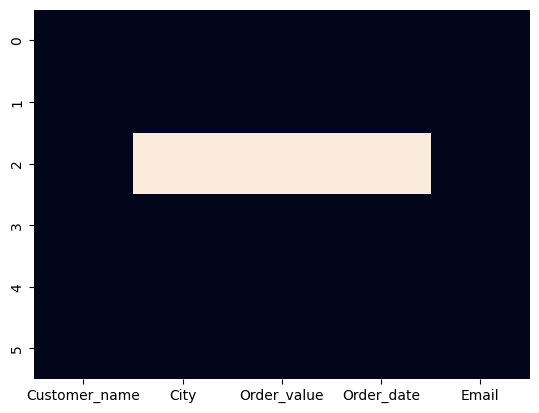

   Customer_name   City  Order_value  Order_date  Email
0          False  False        False       False  False
1          False  False        False       False  False
2          False   True         True        True  False
3          False  False        False       False  False
4          False  False        False       False  False
5          False  False        False       False  False
  Customer_name       City  Order_value  Order_date               Email
0          Asha  Bangalore       5000.0  2024-01-01   asha123@gmail.com
1          Bala      Delhi       7000.0  2024-01-02      bala@gmail.com
2        Chitra        NaN          NaN         NaN  chitra@company.com
3         Deepa      Delhi       6500.0  2024-01-04  deepa_98@yahoo.com
4          Esha  Bangalore       7200.0  2024-01-05      esha@gmail.com
5          Bala     Mumbai       7000.0  2024-01-02      bala@gmail.com


In [10]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data={
    'Customer_name':['Asha','Bala','Chitra','Deepa','Esha','Bala'],
    'City':['Bangalore','Delhi',None,'Delhi','Bangalore','Mumbai'],
    'Order_value':[5000,7000,np.nan,6500,7200,7000],
    'Order_date':['2024-01-01','2024-01-02',None,'2024-01-04','2024-01-05','2024-01-02'],
    'Email':['asha123@gmail.com','bala@gmail.com','chitra@company.com',
             'deepa_98@yahoo.com','esha@gmail.com','bala@gmail.com']
}

df=pd.DataFrame(data)
sns.heatmap(df.isna(),cbar=False)
plt.show()
print(df.isna())
print(df)

sns.heatmap converts df.isna matrix here to colors so missing values appear as highlighted cells. 
Analysts use heatmaps in EDA (Exploratory data analysis)

cbar=color bar(legend)
cbar is set to false because we have only true or false values so color scale is unnecessary


In [18]:
#time series imputation
#interpolate

data={'Order_date':['2024-01-01','2024-01-02','2024-01-03','2024-01-04','2024-01-05'],
      'Sales':[100,np.nan,110,np.nan,120]
     }
df=pd.DataFrame(data)
df['Order_date']=pd.to_datetime(df['Order_date'])
df

,Order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,NaN
2,2024-01-03,110.0
3,2024-01-04,NaN
4,2024-01-05,120.0


In [13]:
df['Sales']=df['Sales'].ffill()
df

,Order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,100.0
2,2024-01-03,110.0
3,2024-01-04,110.0
4,2024-01-05,120.0


In [16]:
df['Sales']=df['Sales'].bfill()
df

,Order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,110.0
2,2024-01-03,110.0
3,2024-01-04,120.0
4,2024-01-05,120.0


In [ ]:
#interpolation estimates the values between two known points
df['Sales']=df['Sales'].interpolate()
df

,Order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,105.0
2,2024-01-03,110.0
3,2024-01-04,115.0
4,2024-01-05,120.0
